
# NLP Final Project – Maintenance Work Order Analysis

## Project Overview
This notebook explores maintenance work order data and builds baseline NLP models.

Goals:
- Clean and understand the dataset
- Compare **pre-2020 vs post-2020** work orders
- Build a **baseline classification model (trade prediction)**
- Compare **TF-IDF vs Word2Vec** for trade prediction
- Explore cost trends
This follows the proposal:
- classify trade
- predict cost
- detect patterns


# Environment Setup

## Overview

This project was developed in **Python** using **Jupyter Notebook** and applies Natural Language Processing (NLP) techniques to maintenance work order data.

The notebook performs:
- Text preprocessing (cleaning, tokenization, TF-IDF)
- Classification (trade prediction)
- Regression (cost prediction)
- Visualization and error analysis

⚠️ **Important:**  
The dataset is **NOT included in this repository** because the CSV files are too large for GitHub. You must download them manually (see Step 4).

## 1. Clone the repository

    git clone https://github.com/CheikhLame/NLP_Project.git
    cd NLP_Project

## 2. Set up environment and install required packages

It is recommended to install the project dependencies in a clean Python environment to avoid conflicts with other packages on your system.

### Create a new environment

**macOS / Linux**

    python3 -m venv env
    source env/bin/activate

**Windows**

    python -m venv env
    env\Scripts\activate

### Install project dependencies

Once the environment is activated, install all required packages using the provided `requirements.txt` file:

    pip install -r requirements.txt

This will install all necessary libraries (pandas, numpy, matplotlib, scikit-learn, seaborn, jupyter, etc.) needed to run the notebook.

## 3. Required Python imports (used in notebook)

The notebook uses the following libraries:

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import re

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report

    # Additional models and utilities
    from sklearn.metrics import confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error
    from sklearn.svm import LinearSVC
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.pipeline import Pipeline

All of these are installed via `requirements.txt`.

## 4. Download dataset (REQUIRED)

Download the dataset from Google Drive:

👉 https://drive.google.com/drive/folders/1dnkfpswJ1R24usBbbxReb3GMPbCEFKnL?usp=drive_link

After downloading, place the CSV files in the same directory as the notebook (`.ipynb`).

## 5. Expected project structure

    NLP_Project/
    ├── nlp_final_project_baseline_ordered.ipynb
    ├── NLP Report 2002-2009.csv
    ├── NLP Report 2010-2019.csv
    ├── NLP Report.csv
    ├── README.md
    ├── requirements.txt
    └── ...

If the CSV files are missing or placed elsewhere, the notebook will not run correctly.

## 6. Launch Jupyter Notebook

    jupyter notebook

Then open the `.ipynb` file and run all cells from top to bottom.

(Optional)

    jupyter lab

## 7. How to run correctly

- Install dependencies using `requirements.txt`  
- Confirm CSV files are in the correct directory  
- Open Jupyter Notebook  
- Run cells in order  
- Restart kernel and rerun if errors occur  

## 8. Common issues and fixes

❌ **FileNotFoundError**  
Cause: CSV files not found  
Fix: Ensure CSVs are in the same folder as the notebook  

❌ **ModuleNotFoundError**  
Cause: Missing package  
Fix:

    pip install -r requirements.txt

❌ **Weird errors / inconsistent results**  
Cause: Cells run out of order or stale variables  
Fix: Restart kernel and run all cells from the top  

❌ **Wrong Python being used**  
Fix:

    which python     # macOS/Linux
    where python     # Windows

Make sure it points to your expected Python installation.

## ✅ Summary

- Clone the repository  
- Install dependencies using `requirements.txt`  
- Download dataset from Google Drive  
- Place CSV files next to the notebook  
- Launch Jupyter Notebook  
- Run all cells in order  

If everything is set up correctly, the notebook should run without errors.

### Additional package for embedding experiment

For the Word2Vec comparison experiment, install **gensim** if it is not already available:

    pip install gensim


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


## Load Data

In [2]:
# -----------------------------
# File paths - stick these bad babies in your projects root directory and you should be good to go. Maybe consider renaming reports later
# -----------------------------
files = [
    "NLP Report 2002-2009.csv",
    "NLP Report 2010-2019.csv",
    "NLP Report.csv",
]

# -----------------------------
# Helper: load one raw export correctly
# -----------------------------
def load_workorder_export(path, encoding="latin1"):
    """
    Loads a Boise State maintenance export where:
    row 0 = export timestamp
    row 1 = report title
    row 2 = blank
    row 3 = actual header row
    row 4+ = data
    """
    raw = pd.read_csv(path, header=None, encoding=encoding, low_memory=False)

    # Header row is index 3
    header = raw.iloc[3, :11].tolist()

    # All the relevant data begins after header
    df = raw.iloc[4:, :11].copy()
    df.columns = header
    df.reset_index(drop=True, inplace=True)

    return df

# -----------------------------
# Load all files
# -----------------------------
dfs = []
for f in files:
    df_part = load_workorder_export(f)
    df_part["source_file"] = f
    dfs.append(df_part)

data = pd.concat(dfs, ignore_index=True)

print("Combined shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


Combined shape: (316979, 12)

Columns:
['Request', 'Building Name', 'Request Date', 'Completion Date', 'Priority Code', 'Priority Description', 'Trade Description', 'Total Hours', 'Total Labor Cost', 'Total Material Cost', 'Total Other Cost', 'source_file']


## Fix Columns

In [3]:
rename_map = {
    "Request": "request_text",
    "Building Name": "building_name",
    "Request Date": "request_date",
    "Completion Date": "completion_date",
    "Priority Code": "priority_code",
    "Priority Description": "priority_description",
    "Trade Description": "trade_description",
    "Total Hours": "total_hours",
    "Total Labor Cost": "total_labor_cost",
    "Total Material Cost": "total_material_cost",
    "Total Other Cost": "total_other_cost",
}

data = data.rename(columns=rename_map)

display(data.head())
print(data.columns.tolist())

,request_text,building_name,request_date,completion_date,priority_code,priority_description,trade_description,total_hours,total_labor_cost,total_material_cost,total_other_cost,source_file
0,"RM 131, 132, 133, 134 TO COLD - Test DB...",Chrisway Annex,10/31/2002,11/04/2002 07:00,1,Routine,HVAC,1.25,$56.25,$0.00,$0.00,NLP Report 2002-2009.csv
1,Closed per Foreman. - Closed per Foreman. - No...,Boulder Hall,10/31/2002,12/16/2017 17:00,1,Routine,Electrician,0.5,$13.80,$0.00,$0.00,NLP Report 2002-2009.csv
2,"Reset fire alarm at fire alarm panel, inside ...",Engineering (RUCH),10/31/2002,12/03/2002 11:12,1,Routine,Electrician,6.25,$172.50,$0.00,"$1,937.30",NLP Report 2002-2009.csv
3,Freezer is not cold.\n\nLA radioed / ml,Copper Basin,10/31/2002,11/15/2002 06:48,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv
4,No air flow.\n\nLarel radioed / ml\nFans down ...,Riverfront Hall,10/31/2002,11/18/2002 07:00,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv


['request_text', 'building_name', 'request_date', 'completion_date', 'priority_code', 'priority_description', 'trade_description', 'total_hours', 'total_labor_cost', 'total_material_cost', 'total_other_cost', 'source_file']


In [4]:
TEXT_COL = "request_text"
LABEL_COL = "trade_description"
DATE_COL = "request_date"

COST_COLS = [
    "total_labor_cost",
    "total_material_cost",
    "total_other_cost"
]

In [5]:
data["total_cost"] = (
    pd.to_numeric(data["total_labor_cost"], errors="coerce").fillna(0)
    + pd.to_numeric(data["total_material_cost"], errors="coerce").fillna(0)
    + pd.to_numeric(data["total_other_cost"], errors="coerce").fillna(0)
)

## Clean Cost Data

In [6]:
# -----------------------------
# Fix text columns
# -----------------------------
data["request_text"] = data["request_text"].astype(str).str.strip()
data["building_name"] = data["building_name"].astype(str).str.strip()
data["trade_description"] = data["trade_description"].astype(str).str.strip()

# Replace empty strings with NaN
data = data.replace({"": np.nan, "nan": np.nan})

# -----------------------------
# Parse dates
# -----------------------------
data["request_date"] = pd.to_datetime(data["request_date"], errors="coerce")
data["completion_date"] = pd.to_datetime(data["completion_date"], errors="coerce")

# -----------------------------
# Convert numeric columns
# -----------------------------
def launderMoney(col): #  RIP Al Capone. Often credited with coining the term "laundering money". 
    return pd.to_numeric(
        col.astype(str)
           .str.replace(r"[\$,]", "", regex=True),
        errors="coerce" # Coerce is a hilarious word to use here. Al Capone probably did a bit of coercing. I'm here all week. 
    )

data["total_labor_cost"] = launderMoney(data["total_labor_cost"])
data["total_material_cost"] = launderMoney(data["total_material_cost"])
data["total_other_cost"] = launderMoney(data["total_other_cost"])

data["total_hours"] = pd.to_numeric(data["total_hours"], errors="coerce")
data["priority_code"] = pd.to_numeric(data["priority_code"], errors="coerce")

# -----------------------------
# NOW create correct total cost
# -----------------------------
data["total_cost"] = (
    data["total_labor_cost"].fillna(0)
    + data["total_material_cost"].fillna(0)
    + data["total_other_cost"].fillna(0)
)

# -----------------------------
# Add year column (needed later)
# -----------------------------
data["request_year"] = data["request_date"].dt.year

# -----------------------------
# Final sanity check
# -----------------------------
print("Dtypes after cleaning:")
print(data.dtypes)

print("\nCost sample:")
display(data[["total_labor_cost", "total_material_cost", "total_other_cost", "total_cost"]].head())

print("\nCost stats:")
display(data["total_cost"].describe())

Dtypes after cleaning:
request_text                    object
building_name                   object
request_date            datetime64[ns]
completion_date         datetime64[ns]
priority_code                  float64
priority_description            object
trade_description               object
total_hours                    float64
total_labor_cost               float64
total_material_cost            float64
total_other_cost               float64
source_file                     object
total_cost                     float64
request_year                   float64
dtype: object

Cost sample:


,total_labor_cost,total_material_cost,total_other_cost,total_cost
0,56.25,0.0,0.0,56.25
1,13.80,0.0,0.0,13.80
2,172.50,0.0,1937.3,2109.80
3,6.63,0.0,0.0,6.63
4,6.63,0.0,0.0,6.63



Cost stats:


count    316979.000000
mean        276.868069
std        1935.468963
min       -3098.000000
25%          11.400000
50%          45.000000
75%         121.420000
max      293934.190000
Name: total_cost, dtype: float64

In [7]:
pre_2020 = data[data["request_year"] < 2020]
post_2020 = data[data["request_year"] >= 2020]

def summarize(df, name):
    print(f"\n===== {name} =====")
    print("Rows:", len(df))
    print("Missing cost %:", df["total_cost"].isna().mean())
    print("Avg cost:", df["total_cost"].mean())
    print("Avg text length:", df["request_text"].str.len().mean())
    print("Unique trades:", df["trade_description"].nunique())

summarize(pre_2020, "PRE 2020")
summarize(post_2020, "POST 2020")


===== PRE 2020 =====
Rows: 226025
Missing cost %: 0.0
Avg cost: 260.4613348523393
Avg text length: 157.37668514593906
Unique trades: 43

===== POST 2020 =====
Rows: 90951
Missing cost %: 0.0
Avg cost: 317.6500566238964
Avg text length: 245.43305736055677
Unique trades: 24


We observed that post-2020 work order descriptions were significantly longer (245 vs 157 characters on average), indicating improved data quality and richer textual information. Additionally, the number of unique trade categories decreased from 43 to 24, suggesting increased standardization in classification. Based on these findings, we used the full dataset for classification tasks while prioritizing post-2020 data for cost prediction models.

## Trade Label Standardization

In [8]:
data["trade_description"].value_counts().head(30)

trade_description
HVAC                               83668
Plumber                            42391
Electrician                        36245
Maintenance Department Services    32340
Custodian                          22179
locksmith                          14822
Life Safety                        10779
Central Receiving                   9646
Movers                              8739
Landscape                           8180
Sr. Maintenance Craftsman           6576
Food Service                        6318
Elevator Maintenance                5073
~Painter                            4563
~SPC                                3950
Custodian Foreman                   3925
Auto Mechanic                       3789
Irrigation Specialist               3662
Pool Operator                       2561
Project Manager                     1684
~Carpenter                          1301
~Cust Maint Craftsman               1197
~Carpenter - Construct               992
Administrative                       79

In [9]:
data["trade_description"] = (
    data["trade_description"]
    .str.lower()
    .str.strip()
    .str.replace("~", "", regex=False)
)

In [10]:
trade_map = {
    # core trades
    "plumber": "plumbing",
    "electrician": "electrical",
    "hvac": "hvac",
    "locksmith": "locksmith",
    "landscape": "landscape",
    "painter": "painting",
    "carpenter": "carpentry",
    
    # variants
    "carpenter - construct": "carpentry",
    "cust maint craftsman": "maintenance",
    "sr. maintenance craftsman": "maintenance",
    "maintenance department services": "maintenance",
    
    # custodial
    "custodian": "custodial",
    "custodian foreman": "custodial",
    
    # mechanical / equipment
    "auto mechanic": "mechanical",
    "pool operator": "mechanical",
    "elevator maintenance": "mechanical",
    
    # safety
    "life safety": "safety",
    "occupational safety": "safety",
    "safety_ehss": "safety",
    
    # food / misc
    "food service": "food_service",
    
    # receiving / moving
    "central receiving": "logistics",
    "movers": "logistics",
    
    # irrigation
    "irrigation specialist": "landscape",
}

In [11]:
data["trade_clean"] = data["trade_description"].replace(trade_map)

In [12]:
bad_classes = [
    "project manager",
    "administrative",
    "supervisor",
    "event services",
    "bldg facility specialist",
]

data = data[~data["trade_clean"].isin(bad_classes)]

In [13]:
counts = data["trade_clean"].value_counts()

valid_classes = counts[counts >= 1000].index

data = data[data["trade_clean"].isin(valid_classes)]

In [14]:
print("Final class counts:")
display(data["trade_clean"].value_counts())

Final class counts:


trade_clean
hvac            83668
plumbing        42391
maintenance     40113
electrical      36245
custodial       26104
logistics       18385
locksmith       14822
landscape       11842
mechanical      11423
safety          11304
food_service     6318
painting         4563
spc              3950
carpentry        2293
Name: count, dtype: int64

Raw trade labels contained inconsistencies, role-based categories, and system-generated prefixes. We normalized labels and grouped semantically similar categories into a reduced set of meaningful trade classes. Additionally, rare and non-operational categories were removed to improve model performance and interpretability.

In [15]:
data = data[data["trade_clean"] != "spc"]

## NLP Preparation

In [16]:
data = data.dropna(subset=["request_text", "trade_clean"])

X = data["request_text"]
y = data["trade_clean"]

In [17]:
def clean_text(text):
    text = text.lower()
    
    # remove newlines
    text = text.replace("\n", " ")
    
    # remove non-alphanumeric (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

X_clean = X.apply(clean_text)

display(X_clean.head())

0         rm 131 132 133 134 to cold test db migration
1    closed per foreman closed per foreman no elect...
2    reset fire alarm at fire alarm panel inside of...
3                    freezer is not cold la radioed ml
4    no air flow larel radioed ml fans down per lar...
Name: request_text, dtype: object

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

In [21]:
def add_keywords(text):
    text = text.lower()
    
    if any(word in text for word in ["paint", "painted", "repaint"]):
        text += " painting_keyword"
        
    if any(word in text for word in ["door", "frame", "wood", "cabinet"]):
        text += " carpentry_keyword"
        
    return text

X_clean = X_clean.apply(add_keywords)

## TF-IDF Baseline Model

In [47]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------
# Prepare modeling data
# -----------------------------
model_df = data.dropna(subset=["request_text", "trade_clean"]).copy()

X = model_df["request_text"]
y = model_df["trade_clean"]

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_clean = X.apply(clean_text)

# Optional keyword boosting
def add_keywords(text):
    if any(word in text for word in ["paint", "painted", "repaint", "primer"]):
        text += " painting_keyword"
    if any(word in text for word in ["door", "frame", "wood", "cabinet", "trim"]):
        text += " carpentry_keyword"
    return text

X_clean = X_clean.apply(add_keywords)

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Vectorize
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 4),
    min_df=10,
    max_df=0.7,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

# -----------------------------
# Train model
# -----------------------------
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train matrix shape: (247572, 8000)
Test matrix shape: (61893, 8000)
Accuracy: 0.8857867610230559

Classification Report:

              precision    recall  f1-score   support

   carpentry       0.24      0.68      0.36       459
   custodial       0.90      0.88      0.89      5221
  electrical       0.89      0.81      0.85      7249
food_service       0.94      0.99      0.97      1264
        hvac       0.98      0.94      0.96     16732
   landscape       0.68      0.94      0.79      2368
   locksmith       0.87      0.94      0.90      2964
   logistics       0.94      0.96      0.95      3677
 maintenance       0.91      0.74      0.82      8022
  mechanical       0.78      0.91      0.84      2285
    painting       0.63      0.84      0.72       913
    plumbing       0.93      0.88      0.91      8478
      safety       0.79      0.98      0.87      2261

    accuracy                           0.89     61893
   macro avg       0.81      0.88      0.83     61893
weighted avg

In [48]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)

print("LinearSVC Accuracy:", accuracy_score(y_test, svm_pred))
print("\nLinearSVC Classification Report:\n")
print(classification_report(y_test, svm_pred))

LinearSVC Accuracy: 0.8952385568642658

LinearSVC Classification Report:

              precision    recall  f1-score   support

   carpentry       0.31      0.57      0.40       459
   custodial       0.90      0.90      0.90      5221
  electrical       0.88      0.82      0.85      7249
food_service       0.97      0.99      0.98      1264
        hvac       0.98      0.95      0.97     16732
   landscape       0.69      0.92      0.79      2368
   locksmith       0.87      0.94      0.91      2964
   logistics       0.94      0.96      0.95      3677
 maintenance       0.90      0.78      0.84      8022
  mechanical       0.81      0.88      0.85      2285
    painting       0.68      0.82      0.75       913
    plumbing       0.92      0.89      0.91      8478
      safety       0.83      0.96      0.89      2261

    accuracy                           0.90     61893
   macro avg       0.82      0.88      0.84     61893
weighted avg       0.90      0.90      0.90     61893



## Word2Vec Experiment

This experiment keeps the same cleaned text and class labels as the TF-IDF baseline, but replaces sparse TF-IDF features with dense word embeddings.

### Plan
- tokenize each cleaned work order
- train a Word2Vec model on the training split only
- average word vectors to create one vector per document
- train a classifier on those document vectors
- compare the results against the TF-IDF baseline

This gives us a second modeling approach that captures word similarity instead of only word frequency.


In [51]:

# ------------------------------------------------------------
# Word2Vec trade classification experiment
# ------------------------------------------------------------
# If gensim is missing in your notebook environment, uncomment the next line:
# %pip install gensim

from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np
import pandas as pd

# Tokenize after cleaning / keyword augmentation
train_tokens = X_train.apply(str.split)
test_tokens = X_test.apply(str.split)

# Train Word2Vec on TRAINING text only to avoid leaking test information
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,          # skip gram
    epochs=15, #maybe 15 is too much. IDK. we can mess with it later. 
    seed=42
)

def average_word_vectors(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.vstack([average_word_vectors(tokens, w2v_model) for tokens in train_tokens])
X_test_w2v = np.vstack([average_word_vectors(tokens, w2v_model) for tokens in test_tokens])

print("Word2Vec train matrix shape:", X_train_w2v.shape)
print("Word2Vec test matrix shape:", X_test_w2v.shape)

w2v_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

w2v_clf.fit(X_train_w2v, y_train)
w2v_pred = w2v_clf.predict(X_test_w2v)

print("Word2Vec Accuracy:", accuracy_score(y_test, w2v_pred))
print("Word2Vec Macro F1:", f1_score(y_test, w2v_pred, average="macro"))
print("\nWord2Vec Classification Report:\n")
print(classification_report(y_test, w2v_pred))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec train matrix shape: (247572, 100)
Word2Vec test matrix shape: (61893, 100)
Word2Vec Accuracy: 0.8367182072286042
Word2Vec Macro F1: 0.7787470329241312

Word2Vec Classification Report:

              precision    recall  f1-score   support

   carpentry       0.18      0.71      0.29       459
   custodial       0.83      0.78      0.81      5221
  electrical       0.85      0.74      0.79      7249
food_service       0.92      0.99      0.95      1264
        hvac       0.98      0.92      0.95     16732
   landscape       0.59      0.91      0.71      2368
   locksmith       0.85      0.92      0.88      2964
   logistics       0.92      0.96      0.94      3677
 maintenance       0.86      0.62      0.72      8022
  mechanical       0.67      0.86      0.76      2285
    painting       0.53      0.83      0.65       913
    plumbing       0.91      0.85      0.88      8478
      safety       0.69      0.95      0.79      2261

    accuracy                           0.84     

In [52]:

# ------------------------------------------------------------
# Quick side by side comparison
# ------------------------------------------------------------
tfidf_accuracy = accuracy_score(y_test, svm_pred)
tfidf_macro_f1 = f1_score(y_test, svm_pred, average="macro")

comparison = pd.DataFrame({
    "model": ["TF-IDF + LinearSVC", "Word2Vec Avg + LogisticRegression"],
    "accuracy": [tfidf_accuracy, accuracy_score(y_test, w2v_pred)],
    "macro_f1": [tfidf_macro_f1, f1_score(y_test, w2v_pred, average="macro")]
})

comparison.sort_values("macro_f1", ascending=False)


,model,accuracy,macro_f1
0,TF-IDF + LinearSVC,0.895239,0.843283
1,Word2Vec Avg + LogisticRegression,0.836718,0.778747



## Observations

- Pre vs Post 2020 differences may indicate improved data quality
- Many low-cost or routine jobs dominate dataset
- TF-IDF gives a strong sparse baseline for trade classification
- Word2Vec provides a second experiment that may capture similarity between related maintenance terms
- The side by side comparison helps show whether semantic embeddings actually improve performance on this dataset

Next steps:
- Try excluding pre-2020 data
- Tune Word2Vec hyperparameters like vector size, window, and min_count
- Try regression for cost prediction
- Try clustering for pattern detection


## Building Clean regression dataset for cost predictions

In [53]:
reg_df = data.copy()

# Keep only rows with real cost info
reg_df = reg_df[
    reg_df["total_labor_cost"].notna() |
    reg_df["total_material_cost"].notna() |
    reg_df["total_other_cost"].notna()
].copy()

# Recompute total cost WITHOUT fake zeros
reg_df["total_cost"] = (
    reg_df["total_labor_cost"].fillna(0) +
    reg_df["total_material_cost"].fillna(0) +
    reg_df["total_other_cost"].fillna(0)
)

# Remove zero-cost rows (usually noise / admin)
reg_df = reg_df[reg_df["total_cost"] > 0]

print("Regression dataset size:", len(reg_df))

Regression dataset size: 253268


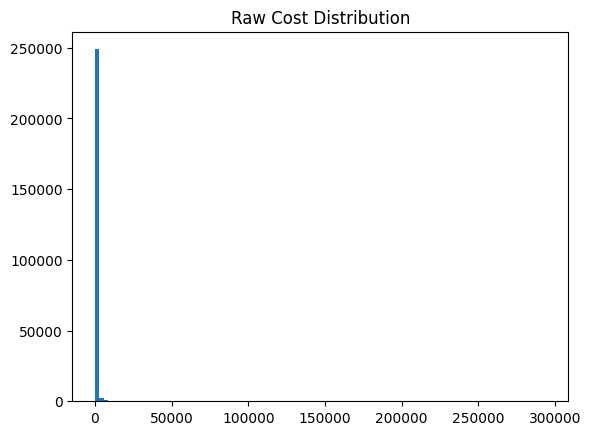

In [54]:
import matplotlib.pyplot as plt

plt.hist(reg_df["total_cost"], bins=100)
plt.title("Raw Cost Distribution")
plt.show()

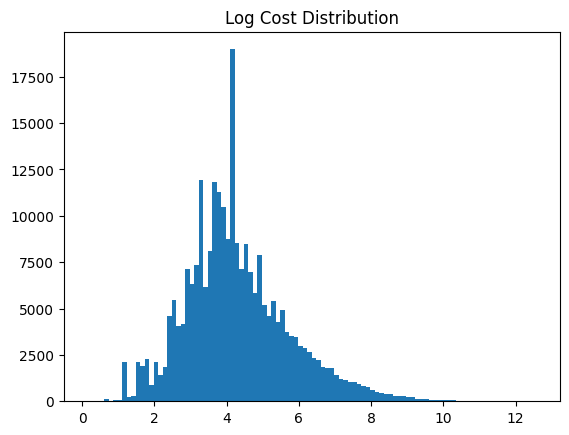

In [55]:
reg_df["log_cost"] = np.log1p(reg_df["total_cost"])

plt.hist(reg_df["log_cost"], bins=100)
plt.title("Log Cost Distribution")
plt.show()

In [56]:
X = reg_df["request_text"]
y = reg_df["log_cost"]

X_clean = X.apply(clean_text)
X_clean = X_clean.apply(add_keywords)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.1,
    random_state=42
)

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1,3),  # trigrams baby
    min_df=10,
    max_df=0.8,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [61]:
upper_limit = reg_df["total_cost"].quantile(0.99)

reg_df = reg_df[reg_df["total_cost"] <= upper_limit]

In [62]:
def add_project_flag(text):
    project_terms = ["contract", "proposal", "invoice", "project", "bid"]
    
    if any(term in text for term in project_terms):
        return 1
    return 0

reg_df["is_project"] = reg_df["request_text"].apply(add_project_flag)

In [63]:
from sklearn.preprocessing import OneHotEncoder

trade_encoded = pd.get_dummies(reg_df["trade_clean"])

In [64]:

# ------------------------------------------------------------
# Word2Vec trade classification experiment
# ------------------------------------------------------------
# If gensim is missing in your notebook environment, uncomment the next line:
# %pip install gensim

from gensim.models import Word2Vec
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Tokenize after cleaning / keyword augmentation
train_tokens = X_train.apply(str.split)
test_tokens = X_test.apply(str.split)

# Train Word2Vec on TRAINING text only to avoid leaking test information
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,          # skip gram
    epochs=15,
    seed=42
)

def average_word_vectors(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.vstack([average_word_vectors(tokens, w2v_model) for tokens in train_tokens])
X_test_w2v = np.vstack([average_word_vectors(tokens, w2v_model) for tokens in test_tokens])

print("Word2Vec train matrix shape:", X_train_w2v.shape)
print("Word2Vec test matrix shape:", X_test_w2v.shape)

w2v_reg = Ridge(alpha=1.0)
w2v_reg.fit(X_train_w2v, y_train)

w2v_pred = w2v_reg.predict(X_test_w2v)

rmse = np.sqrt(mean_squared_error(y_test, w2v_pred))
mae = mean_absolute_error(y_test, w2v_pred)
r2 = r2_score(y_test, w2v_pred)

print("Word2Vec MAE:", mae)
print("Word2Vec RMSE:", rmse)
print("Word2Vec R^2:", r2)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec train matrix shape: (227941, 100)
Word2Vec test matrix shape: (25327, 100)
Word2Vec MAE: 0.9116209514587016
Word2Vec RMSE: 1.2035190351043727
Word2Vec R^2: 0.2980096404857906


In [65]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train_vec, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test_vec)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE (log space):", mae)
print("RMSE (log space):", rmse)

MAE (log space): 0.7049532557320871
RMSE (log space): 0.974200743657085


In [67]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("MAE (actual dollars):", mae_actual)
print("RMSE (actual dollars):", rmse_actual)

MAE (actual dollars): 238.01539272147969
RMSE (actual dollars): 1598.66554566529


In [68]:
results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "predicted_cost": y_pred_actual
})

results["abs_error"] = (results["actual_cost"] - results["predicted_cost"]).abs()

display(results.sort_values("abs_error", ascending=False).head(10))

,text,actual_cost,predicted_cost,abs_error
2434,time tracking for call ins related to material...,108622.31,3279.771664,105342.538336
16928,batch closed closed per foreman all pool maint...,62406.28,1348.550181,61057.729819
9710,contractor qei work proposal as per kevin burt...,69887.57,12175.598781,57711.971219
3938,bw 7 5 2016 do not charge all of the invoices ...,59051.88,4290.383973,54761.496027
24422,hvac repair air handler compressor 1b 2a is gr...,49713.43,1146.505333,48566.924667
19002,batch closed plumbers fy 2018 2019 pool mainte...,50726.90,3093.143460,47633.756540
13379,claim 2017 0010 001 traveler s insurance scien...,56499.16,10249.126320,46250.033680
21258,snow removal,42937.46,700.852755,42236.607245
17277,perkins const to act as general contractor for...,41197.60,822.971880,40374.628120
9428,install new 480 v 200 amp panel from mdp for a...,39378.35,788.965652,38589.384348


## Experiment 1, train on reactive WO's only

In [69]:
# ============================================================
# EXPERIMENT: FULL REGRESSION DATA vs REACTIVE-ONLY DATA
# Uses the same style and columns as the notebook above
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. START FROM THE SAME REGRESSION DATASET LOGIC USED ABOVE
# ------------------------------------------------------------
exp_df = data.copy()

# Keep only rows with real cost info
exp_df = exp_df[
    exp_df["total_labor_cost"].notna() |
    exp_df["total_material_cost"].notna() |
    exp_df["total_other_cost"].notna()
].copy()

# Recompute total cost
exp_df["total_cost"] = (
    exp_df["total_labor_cost"].fillna(0) +
    exp_df["total_material_cost"].fillna(0) +
    exp_df["total_other_cost"].fillna(0)
)

# Remove zero-cost rows
exp_df = exp_df[exp_df["total_cost"] > 0].copy()

# Match your notebook's outlier trimming
upper_limit = exp_df["total_cost"].quantile(0.99)
exp_df = exp_df[exp_df["total_cost"] <= upper_limit].copy()

# Match your notebook's log transform
exp_df["log_cost"] = np.log1p(exp_df["total_cost"])

print("Full experiment dataset size:", len(exp_df))

# ------------------------------------------------------------
# 2. DEFINE PM / BATCH-CLOSED FILTER
# ------------------------------------------------------------
def is_pm_or_batch_closed(text):
    text = str(text).lower()

    pm_terms = [
        "preventive maintenance",
        "preventative maintenance",
        "preventive",
        "preventative",
        "pm ",
        " pm",
        "inspection",
        "routine maintenance"
    ]

    batch_terms = [
        "batch closed",
        "closed per foreman",
        "no charge",
        "batchclose",
        "bulk close"
    ]

    return any(term in text for term in pm_terms + batch_terms)

reactive_df = exp_df[~exp_df["request_text"].apply(is_pm_or_batch_closed)].copy()

print("Reactive-only dataset size:", len(reactive_df))
print("Rows removed:", len(exp_df) - len(reactive_df))

# ------------------------------------------------------------
# 3. TRAIN / EVAL FUNCTION THAT MATCHES YOUR NOTEBOOK
# ------------------------------------------------------------
def run_cost_experiment(input_df, label):
    X = input_df["request_text"]
    y = input_df["log_cost"]

    X_clean = X.apply(clean_text)
    X_clean = X_clean.apply(add_keywords)

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean,
        y,
        test_size=0.2,
        random_state=42
    )

    vectorizer = TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        min_df=10,
        max_df=0.8,
        stop_words="english"
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = Ridge(alpha=1.0)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    # log-space metrics
    mae_log = mean_absolute_error(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))

    # actual-dollar metrics
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)

    mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

    results = pd.DataFrame({
        "text": X_test.reset_index(drop=True),
        "actual_cost": y_test_actual.reset_index(drop=True),
        "predicted_cost": y_pred_actual
    })

    results["abs_error"] = (
        results["actual_cost"] - results["predicted_cost"]
    ).abs()

    print(f"\n===== {label} =====")
    print("Rows used:", len(input_df))
    print("MAE (log space):", mae_log)
    print("RMSE (log space):", rmse_log)
    print("MAE (actual dollars):", mae_actual)
    print("RMSE (actual dollars):", rmse_actual)

    display(results.sort_values("abs_error", ascending=False).head(10))

    return {
        "label": label,
        "rows": len(input_df),
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "mae_actual": mae_actual,
        "rmse_actual": rmse_actual,
        "results": results,
        "model": model,
        "vectorizer": vectorizer
    }

# ------------------------------------------------------------
# 4. RUN BOTH MODELS
# ------------------------------------------------------------
full_model_results = run_cost_experiment(exp_df, "FULL DATA MODEL")
reactive_model_results = run_cost_experiment(reactive_df, "REACTIVE-ONLY MODEL")

# ------------------------------------------------------------
# 5. COMPARE RESULTS
# ------------------------------------------------------------
comparison_df = pd.DataFrame([
    {
        "model": full_model_results["label"],
        "rows_used": full_model_results["rows"],
        "mae_log": full_model_results["mae_log"],
        "rmse_log": full_model_results["rmse_log"],
        "mae_actual": full_model_results["mae_actual"],
        "rmse_actual": full_model_results["rmse_actual"]
    },
    {
        "model": reactive_model_results["label"],
        "rows_used": reactive_model_results["rows"],
        "mae_log": reactive_model_results["mae_log"],
        "rmse_log": reactive_model_results["rmse_log"],
        "mae_actual": reactive_model_results["mae_actual"],
        "rmse_actual": reactive_model_results["rmse_actual"]
    }
])

print("\n===== FINAL COMPARISON =====")
display(comparison_df)

if reactive_model_results["rmse_actual"] < full_model_results["rmse_actual"]:
    print("Reactive-only model has lower RMSE in actual dollars.")
else:
    print("Full-data model has lower RMSE in actual dollars.")

if reactive_model_results["mae_actual"] < full_model_results["mae_actual"]:
    print("Reactive-only model has lower MAE in actual dollars.")
else:
    print("Full-data model has lower MAE in actual dollars.")

Full experiment dataset size: 250735
Reactive-only dataset size: 179352
Rows removed: 71383

===== FULL DATA MODEL =====
Rows used: 250735
MAE (log space): 0.7159974391233449
RMSE (log space): 0.9683530452980184
MAE (actual dollars): 143.64570932486774
RMSE (actual dollars): 413.7163644812251


,text,actual_cost,predicted_cost,abs_error
13995,the doors all need to be cleaned varnished the...,4545.79,45.160298,4500.629702
45439,daily building checks and minor maintenance,4657.50,162.619479,4494.880521
33774,please re key all non assa doors on the second...,4665.68,183.917095,4481.762905
21989,purchase 45 chairs for mp208 and 25 chairs for...,4662.32,189.024719,4473.295281
38622,turf maintenance mowing,4691.70,246.310001,4445.389999
46090,please move all furniture and boxes out of a 3...,4525.34,81.619663,4443.720337
46611,hvac called in middle of the night for hvac hy...,4579.92,139.485688,4440.434312
7255,hardscape maintenance sweeping vacuuming parki...,4660.90,223.006997,4437.893003
48870,maint various amount of patching painting disa...,4568.50,161.919308,4406.580692
13116,daily building checks and minor maintenance,4540.60,162.619479,4377.980521



===== REACTIVE-ONLY MODEL =====
Rows used: 179352
MAE (log space): 0.7637255054724248
RMSE (log space): 1.0239339945684534
MAE (actual dollars): 166.45120570197665
RMSE (actual dollars): 456.7137917474801


,text,actual_cost,predicted_cost,abs_error
34344,replace vfd with a danfoss model replace origi...,4604.55,87.798355,4516.751645
25314,campus steam water test treatment,4659.84,160.241651,4499.598349
21339,replace vfd with a danfoss model replace origi...,4555.17,87.798355,4467.371645
26952,maint install blinds in 302 in the norco build...,4672.23,230.443213,4441.786787
27600,painter radar paint interior offices and main ...,4638.73,205.276034,4433.453966
7093,hvac safety valve biennial certification,4593.25,197.332772,4395.917228
22124,turf maintenance weed control,4603.21,253.284277,4349.925723
32684,campus steam water test treatment,4501.99,160.241651,4341.748349
22130,i need a manitenance work order for doing main...,4606.22,279.441160,4326.778840
21290,lockshop provide quote for installing card rea...,4663.41,363.881308,4299.528692



===== FINAL COMPARISON =====


,model,rows_used,mae_log,rmse_log,mae_actual,rmse_actual
0,FULL DATA MODEL,250735,0.715997,0.968353,143.645709,413.716364
1,REACTIVE-ONLY MODEL,179352,0.763726,1.023934,166.451206,456.713792


Full-data model has lower RMSE in actual dollars.
Full-data model has lower MAE in actual dollars.


In [70]:
# ============================================================
# WORST PREDICTIONS ANALYSIS (FINAL)
# ============================================================

# -----------------------------
# FULL MODEL - WORST 100
# -----------------------------
full_worst_100 = (
    full_model_results["results"]
    .sort_values("abs_error", ascending=False)
    .head(100)
    .copy()
)

# Add error ratio (avoid divide-by-zero just in case)
full_worst_100["error_ratio"] = (
    full_worst_100["abs_error"] / full_worst_100["actual_cost"].replace(0, np.nan)
)

# Export to CSV
full_worst_100.to_csv("full_model_worst_100.csv", index=False)


# -----------------------------
# REACTIVE MODEL - WORST 100
# -----------------------------
reactive_worst_100 = (
    reactive_model_results["results"]
    .sort_values("abs_error", ascending=False)
    .head(100)
    .copy()
)

# Add error ratio
reactive_worst_100["error_ratio"] = (
    reactive_worst_100["abs_error"] / reactive_worst_100["actual_cost"].replace(0, np.nan)
)

# Export to CSV
reactive_worst_100.to_csv("reactive_model_worst_100.csv", index=False)


# ============================================================
# DISPLAY TOP 10 ONLY (CLEAN OUTPUT)
# ============================================================

print("\n===== FULL MODEL: TOP 10 WORST =====")
display(full_worst_100.head(10))

print("\n===== REACTIVE MODEL: TOP 10 WORST =====")
display(reactive_worst_100.head(10))


===== FULL MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
13995,the doors all need to be cleaned varnished the...,4545.79,45.160298,4500.629702,0.990065
45439,daily building checks and minor maintenance,4657.50,162.619479,4494.880521,0.965084
33774,please re key all non assa doors on the second...,4665.68,183.917095,4481.762905,0.960581
21989,purchase 45 chairs for mp208 and 25 chairs for...,4662.32,189.024719,4473.295281,0.959457
38622,turf maintenance mowing,4691.70,246.310001,4445.389999,0.947501
46090,please move all furniture and boxes out of a 3...,4525.34,81.619663,4443.720337,0.981964
46611,hvac called in middle of the night for hvac hy...,4579.92,139.485688,4440.434312,0.969544
7255,hardscape maintenance sweeping vacuuming parki...,4660.90,223.006997,4437.893003,0.952154
48870,maint various amount of patching painting disa...,4568.50,161.919308,4406.580692,0.964557
13116,daily building checks and minor maintenance,4540.60,162.619479,4377.980521,0.964185



===== REACTIVE MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
34344,replace vfd with a danfoss model replace origi...,4604.55,87.798355,4516.751645,0.980932
25314,campus steam water test treatment,4659.84,160.241651,4499.598349,0.965612
21339,replace vfd with a danfoss model replace origi...,4555.17,87.798355,4467.371645,0.980726
26952,maint install blinds in 302 in the norco build...,4672.23,230.443213,4441.786787,0.950678
27600,painter radar paint interior offices and main ...,4638.73,205.276034,4433.453966,0.955747
7093,hvac safety valve biennial certification,4593.25,197.332772,4395.917228,0.957039
22124,turf maintenance weed control,4603.21,253.284277,4349.925723,0.944977
32684,campus steam water test treatment,4501.99,160.241651,4341.748349,0.964406
22130,i need a manitenance work order for doing main...,4606.22,279.441160,4326.778840,0.939334
21290,lockshop provide quote for installing card rea...,4663.41,363.881308,4299.528692,0.921971


What this block does:
trains one model on all non-user rows
trains one model on reactive-only non-user rows
tests both on the same user-entered rows only
That makes this a much cleaner experiment than your earlier split, because both models are judged on the same target population.


In [71]:
# ============================================================
# WORST PREDICTIONS ANALYSIS (FINAL)
# ============================================================

# -----------------------------
# FULL MODEL - WORST 100
# -----------------------------
full_worst_100 = (
    full_model_results["results"]
    .sort_values("abs_error", ascending=False)
    .head(100)
    .copy()
)

# Add error ratio (avoid divide-by-zero just in case)
full_worst_100["error_ratio"] = (
    full_worst_100["abs_error"] / full_worst_100["actual_cost"].replace(0, np.nan)
)

# Export to CSV
full_worst_100.to_csv("full_model_worst_100.csv", index=False)


# -----------------------------
# REACTIVE MODEL - WORST 100
# -----------------------------
reactive_worst_100 = (
    reactive_model_results["results"]
    .sort_values("abs_error", ascending=False)
    .head(100)
    .copy()
)

# Add error ratio
reactive_worst_100["error_ratio"] = (
    reactive_worst_100["abs_error"] / reactive_worst_100["actual_cost"].replace(0, np.nan)
)

# Export to CSV
reactive_worst_100.to_csv("reactive_model_worst_100.csv", index=False)


# ============================================================
# DISPLAY TOP 10 ONLY (CLEAN OUTPUT)
# ============================================================

print("\n===== FULL MODEL: TOP 10 WORST =====")
display(full_worst_100.head(10))

print("\n===== REACTIVE MODEL: TOP 10 WORST =====")
display(reactive_worst_100.head(10))


===== FULL MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
13995,the doors all need to be cleaned varnished the...,4545.79,45.160298,4500.629702,0.990065
45439,daily building checks and minor maintenance,4657.50,162.619479,4494.880521,0.965084
33774,please re key all non assa doors on the second...,4665.68,183.917095,4481.762905,0.960581
21989,purchase 45 chairs for mp208 and 25 chairs for...,4662.32,189.024719,4473.295281,0.959457
38622,turf maintenance mowing,4691.70,246.310001,4445.389999,0.947501
46090,please move all furniture and boxes out of a 3...,4525.34,81.619663,4443.720337,0.981964
46611,hvac called in middle of the night for hvac hy...,4579.92,139.485688,4440.434312,0.969544
7255,hardscape maintenance sweeping vacuuming parki...,4660.90,223.006997,4437.893003,0.952154
48870,maint various amount of patching painting disa...,4568.50,161.919308,4406.580692,0.964557
13116,daily building checks and minor maintenance,4540.60,162.619479,4377.980521,0.964185



===== REACTIVE MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
34344,replace vfd with a danfoss model replace origi...,4604.55,87.798355,4516.751645,0.980932
25314,campus steam water test treatment,4659.84,160.241651,4499.598349,0.965612
21339,replace vfd with a danfoss model replace origi...,4555.17,87.798355,4467.371645,0.980726
26952,maint install blinds in 302 in the norco build...,4672.23,230.443213,4441.786787,0.950678
27600,painter radar paint interior offices and main ...,4638.73,205.276034,4433.453966,0.955747
7093,hvac safety valve biennial certification,4593.25,197.332772,4395.917228,0.957039
22124,turf maintenance weed control,4603.21,253.284277,4349.925723,0.944977
32684,campus steam water test treatment,4501.99,160.241651,4341.748349,0.964406
22130,i need a manitenance work order for doing main...,4606.22,279.441160,4326.778840,0.939334
21290,lockshop provide quote for installing card rea...,4663.41,363.881308,4299.528692,0.921971


# NLP Cost Prediction – Model Comparison (TF-IDF vs Word2Vec)

## Overview

In this project, we explored different approaches for predicting maintenance work order costs based on short text descriptions. The primary goal was to determine whether more advanced NLP techniques (like Word2Vec embeddings) provide better predictive performance than a traditional baseline (TF-IDF).

The dataset consists of short, often noisy maintenance descriptions such as:
- "leak under sink"
- "replace door hinge"
- "paint hallway wall"

These descriptions are typically brief and heavily driven by specific keywords rather than complex sentence structure.

---

## Models Compared

### 1. TF-IDF Baseline
The baseline model uses:
- TF-IDF vectorization of text
- Ridge regression for cost prediction

This approach treats each document as a bag of words and assigns importance based on term frequency and inverse document frequency.

---

### 2. Word2Vec Embedding Model
The experimental model uses:
- Word2Vec to learn vector embeddings for words
- Averaging of word vectors to create document-level representations
- Ridge regression for cost prediction

The goal of this approach is to capture semantic relationships between words (e.g., "paint" and "repaint" being similar).

---

## Results

### TF-IDF Performance
- MAE (actual dollars): **~144**
- RMSE (actual dollars): **~414**

### Word2Vec Performance
- MAE (actual dollars): **~254**
- RMSE (actual dollars): **~1678**
- R²: **~0.30**

---

## Key Findings

### 1. TF-IDF significantly outperformed Word2Vec

The TF-IDF model produced much lower error across all metrics. In particular:
- Word2Vec had ~76% higher MAE
- Word2Vec had ~4x higher RMSE

This indicates that Word2Vec made substantially larger mistakes, especially on higher-cost work orders.

---

### 2. The dataset is highly keyword-driven

The main reason TF-IDF performed better is that the dataset relies heavily on specific keywords to indicate the type and scope of work. For example:
- "leak" → plumbing
- "paint" → painting
- "compressor" → expensive HVAC work

TF-IDF preserves these exact terms and assigns them strong importance.

In contrast, Word2Vec averages word embeddings, which can dilute the impact of these high-signal words.

---

### 3. Averaging Word2Vec embeddings loses important information

In the Word2Vec approach, each document is represented by the average of its word vectors. This causes:
- Important keywords to be blended with less important words
- Loss of sharp distinctions between low-cost and high-cost jobs

This is especially problematic for short text, where each word carries a lot of meaning.

---

### 4. Word2Vec struggled with high-cost outliers

The large gap between MAE and RMSE in the Word2Vec model suggests that:
- The model performs reasonably on average cases
- But fails on expensive or complex jobs

This is common in cost prediction problems where a small number of high-cost jobs dominate the error.

---

## Conclusion

Although Word2Vec is a more advanced NLP technique that captures semantic relationships between words, it did not outperform TF-IDF in this case.

This suggests that:
- The maintenance work order data is not rich in semantic structure
- Instead, it is dominated by short, keyword-based descriptions
- Preserving exact word frequency (TF-IDF) is more effective than using averaged embeddings

As a result, the TF-IDF + Ridge regression model remains the best-performing approach for this dataset.

---

## Future Improvements

Potential ways to improve performance include:
- Adding structured features (trade, building, priority, etc.)
- Engineering keyword-based features (e.g., "replace", "emergency")
- Trying hybrid models (TF-IDF + embeddings)
- Exploring non-linear models (e.g., tree-based regressors)m

---

## Final Takeaway

More complex NLP models do not automatically lead to better performance. Model effectiveness depends heavily on the structure of the data. In this case, a simpler, keyword-focused approach proved to be more reliable and accurate.